In [1]:
from pathlib import Path
from PIL import Image
from torchvision import transforms
import torch

import copy
import torch.nn as nn

# Load the CNN Model

In [2]:
# Use metal performance shaders (MPS) if available

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Usando dispositivo:", device)


Usando dispositivo: mps


In [3]:
#Load the model and configure for the device


model_path = "Models/Model_Exec_711_Epoch_150_cpu_portable_full.pt"

values = torch.load(model_path, map_location="cpu", weights_only=False)
model = values["modelo"]

model = model.to(device)
model.eval()

print("Modelo cargado correctamente")

Modelo cargado correctamente


# Capture the tensor and convert to vector

In [4]:
#Tensor from model to vector[1024] extracter:

#TODO: Check if the forward function is exactliy the same as the one in the original model.

class CNNEmbeddingExtractor(nn.Module):
    def __init__(self, base_model):
        super().__init__()

        self.features = nn.ModuleList([
            nn.Sequential(*copy.deepcopy(block))
            for block in base_model.features
        ])

        self.second_level = copy.deepcopy(base_model.second_level)
        self.sizes = copy.deepcopy(base_model.sizes)

    def forward(self, image):
        x = image
        prev = -1
        pos = 0
        outputs = {}

        for i in range(len(self.features)):
            if i == 0 or i == 1:
                x = self.features[i](x)
                outputs[i] = x
            else:
                connections = self.second_level[pos:pos+prev]

                for c in range(len(connections)):
                    if connections[c] == 1:
                        skip_size = self.sizes[c][0]
                        req_size = x.shape[2]

                        if skip_size > req_size:
                            psize = skip_size - req_size + 1
                            pool = nn.MaxPool2d(kernel_size=psize, stride=1)
                            x2 = pool(outputs[c])

                        elif skip_size == req_size:
                            x2 = outputs[c]

                        else:
                            if (req_size - skip_size) % 2 == 0:
                                pad = int((req_size - skip_size) / 2)
                                padding = nn.ZeroPad2d(pad)
                                x2 = padding(outputs[c])
                            else:
                                pool = nn.MaxPool2d(kernel_size=2, stride=1, padding=1)
                                x2 = pool(outputs[c])
                                pad = int((req_size - skip_size - 1) / 2)
                                if pad > 0:
                                    padding = nn.ZeroPad2d(pad)
                                    x2 = padding(x2)

                        x = torch.cat((x, x2), axis=1)

                x = self.features[i](x)
                outputs[i] = x
                pos += prev

            prev += 1

        return torch.flatten(x, 1)

# Load the image and get the Vector [1024]

In [5]:
#Transformer for the image

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [6]:
#Obtain the vector for a real image

extractor = CNNEmbeddingExtractor(model)
extractor = extractor.to(device)
extractor.eval()

def get_embedding_from_image(image_path, extractor, transform):
    img = Image.open(image_path)
    x = transform(img).unsqueeze(0).to(device)  # [1,1,128,128]

    with torch.no_grad():
        #emb = extractor.forward(x) 
        emb = extractor(x)  # [1,1024]

    return emb.squeeze(0).detach().cpu()

In [7]:
def build_embedding_dict(root_dir, extractor, transform, valid_exts=None):
    if valid_exts is None:
        valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

    root_dir = Path(root_dir)
    embedding_dict = {}
    failed_files = []

    all_files = sorted(root_dir.rglob("*"))

    for file_path in all_files:
        if file_path.is_file() and file_path.suffix.lower() in valid_exts:
            try:
                relative_key = str(file_path.relative_to(root_dir))

                emb = get_embedding_from_image(
                    image_path=file_path,
                    extractor=extractor,
                    transform=transform
                )

                embedding_dict[relative_key] = emb

            except Exception as e:
                failed_files.append((str(file_path), str(e)))

    return embedding_dict, failed_files

In [8]:
#Create the dictonary of embeddings for all the images in the dataset

root_dir = "DataSet/radiografia_dataset_original"

embedding_dict, failed_files = build_embedding_dict( #embedding_dict is the dictionary
    root_dir=root_dir,
    extractor=extractor,
    transform=transform
)

print("Número de embeddings generados:", len(embedding_dict))
print("Número de archivos con error:", len(failed_files))

first_keys = list(embedding_dict.keys())

for k in first_keys:
    print("Ruta: ", k, "Shape: ",  embedding_dict[k].shape, "\n     Vector: ", embedding_dict[k][:5])
print ("\nAnd more ...")

if failed_files:
    print("Archivos con error:")
    for path, err in failed_files[:30]:
        print(path)
        print("Error:", err)
        print("-" * 50)
else:
    print("No hubo errores.")

Número de embeddings generados: 366
Número de archivos con error: 0
Ruta:  Necrosis Pulpar/1. OD 36.jpeg Shape:  torch.Size([18432]) 
     Vector:  tensor([0.0000, 1.0326, 1.0521, 0.2452, 0.0000])
Ruta:  Necrosis Pulpar/10. OD 16.jpg Shape:  torch.Size([18432]) 
     Vector:  tensor([1.4446, 0.6197, 0.0432, 0.0278, 0.0000])
Ruta:  Necrosis Pulpar/100. OD 16.jpg Shape:  torch.Size([18432]) 
     Vector:  tensor([1.5348, 2.1715, 1.8599, 1.1043, 0.9982])
Ruta:  Necrosis Pulpar/11. OD 17.jpg Shape:  torch.Size([18432]) 
     Vector:  tensor([1.1553, 1.0869, 0.6215, 0.0000, 0.0000])
Ruta:  Necrosis Pulpar/12. OD 46.jpg Shape:  torch.Size([18432]) 
     Vector:  tensor([0.0000, 0.0000, 0.0400, 0.5705, 0.9286])
Ruta:  Necrosis Pulpar/13. OD 14.jpg Shape:  torch.Size([18432]) 
     Vector:  tensor([0.9192, 1.0953, 1.6753, 1.7478, 1.5920])
Ruta:  Necrosis Pulpar/14. OD 16.jpg Shape:  torch.Size([18432]) 
     Vector:  tensor([0.0774, 0.4129, 0.7521, 1.1251, 1.0117])
Ruta:  Necrosis Pulpar/15. O

# Create the clinical Vector [11]

In [9]:
#Check the csv
import pandas as pd

df = pd.read_csv("DataSet/dataset_maestro.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(365, 8)
['id', 'external_id', 'Clase', 'Dx Periapical', 'Sensibilidad', 'Percusión', 'Movilidad', 'Palpación']


,id,external_id,Clase,Dx Periapical,Sensibilidad,Percusión,Movilidad,Palpación
0,1. OD 22,radiografia_dataset_original/Pulpa Normal/1. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
1,2. OD 25,radiografia_dataset_original/Pulpa Normal/2. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
2,3. OD 14,radiografia_dataset_original/Pulpa Normal/3. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
3,4. OD 25,radiografia_dataset_original/Pulpa Normal/4. O...,Pulpa Normal,Periodontitis apical sintomática,positivo,positivo,1,negativo
4,5. OD 27,radiografia_dataset_original/Pulpa Normal/5. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo


In [10]:
def build_clinical_vector(dx_periapical, sensibilidad, percusion, movilidad, palpacion):
    # Normalizar strings
    dx_periapical = str(dx_periapical).strip()
    sensibilidad = str(sensibilidad).strip().lower()
    percusion = str(percusion).strip().lower()
    movilidad = str(movilidad).strip()
    palpacion = str(palpacion).strip().lower()

    # Mapeo Dx Periapical
    dx_map = {
        "Periodontitis apical asintomática": [1, 0, 0, 0, 0],
        "Absceso apical crónico":            [0, 1, 0, 0, 0],
        "Periodontitis apical sintomática":  [0, 0, 1, 0, 0],
        "Tejidos apicales normales":         [0, 0, 0, 1, 0],
        "Absceso apical agudo":              [0, 0, 0, 0, 1],
    }

    # Binarias
    bin_map = {
        "positiva": 1.0,
        "positivo": 1.0,
        "negativa": 0.0,
        "negativo": 0.0,
    }

    # Movilidad
    movilidad_map = {
        "No valorable": [0, 0, 0],
        "1":            [1, 0, 0],
        "2":            [0, 1, 0],
        "3":            [0, 0, 1],  
    }

    if dx_periapical not in dx_map:
        raise ValueError(f"Dx Periapical no válido: {dx_periapical}")

    if sensibilidad not in bin_map:
        raise ValueError(f"Sensibilidad no válida: {sensibilidad}")

    if percusion not in bin_map:
        raise ValueError(f"Percusión no válida: {percusion}")

    if palpacion not in bin_map:
        raise ValueError(f"Palpación no válida: {palpacion}")

    if movilidad not in movilidad_map:
        raise ValueError(f"Movilidad no válida: {movilidad}")

    vector = (
        dx_map[dx_periapical]
        + [bin_map[sensibilidad]]
        + [bin_map[percusion]]
        + movilidad_map[movilidad]
        + [bin_map[palpacion]]
    )

    return torch.tensor(vector, dtype=torch.float32)

In [11]:
#This aren't the clases for the vector, this is for the final classification of the model.

class_to_idx = {
    "Necrosis Pulpar": 0,
    "Previamente iniciado": 1,
    "Previamente Tratado": 2,
    "Pulpa Normal": 3,
    "Pulpitis Irreversible Asintomática": 4,
    "Pulpitis Irreversible Sintomática": 5,
    "Pulpitis Reversible": 6,
}

In [12]:
def normalize_image_key(external_id):
    external_id = str(external_id).strip()
    prefix = "radiografia_dataset_original/"
    if external_id.startswith(prefix):
        return external_id[len(prefix):]
    return external_id

# Data Loader step by step

In [13]:
# Create the samples

samples = []
errors = []

for idx, row in df.iterrows():
    try:
        image_key = normalize_image_key(row["external_id"])

        if image_key not in embedding_dict:
            raise KeyError(f"No se encontró embedding para: {image_key}")

        clinical_vector = build_clinical_vector(
            dx_periapical=row["Dx Periapical"],
            sensibilidad=row["Sensibilidad"],
            percusion=row["Percusión"],
            movilidad=row["Movilidad"],
            palpacion=row["Palpación"],
        )

        if row["Clase"] not in class_to_idx:
            raise KeyError(f"Clase no válida: {row['Clase']}")

        label = class_to_idx[row["Clase"]]

        samples.append({
            "image_key": image_key,
            "embedding": embedding_dict[image_key],   # [1024]
            "clinical_vector": clinical_vector,       # [11]
            "label": label,                           # int
        })

    except Exception as e:
        errors.append({
            "row_idx": idx,
            "id": row.get("id", None),
            "external_id": row.get("external_id", None),
            "clase": row.get("Clase", None),
            "dx_periapical": row.get("Dx Periapical", None),
            "sensibilidad": row.get("Sensibilidad", None),
            "percusion": row.get("Percusión", None),
            "movilidad": row.get("Movilidad", None),
            "palpacion": row.get("Palpación", None),
            "error": str(e),
        })

print("Samples válidos:", len(samples))
print("Errores:", len(errors))

for err in errors:
    print("=" * 80)
    print(f"Fila: {err['row_idx']}")
    print(f"id: {err['id']}")
    print(f"external_id: {err['external_id']}")
    print(f"Clase: {err['clase']}")
    print(f"Dx Periapical: {err['dx_periapical']}")
    print(f"Sensibilidad: {err['sensibilidad']}")
    print(f"Percusión: {err['percusion']}")
    print(f"Movilidad: {err['movilidad']}")
    print(f"Palpación: {err['palpacion']}")
    print(f"Error: {err['error']}")

Samples válidos: 364
Errores: 1
Fila: 321
id: 26. OD 21
external_id: Previamente iniciado/26. OD 21.jpg
Clase: Previamente iniciado
Dx Periapical: Tejidos apicales normales
Sensibilidad: negativo
Percusión: negativo
Movilidad: 1
Palpación: negativo
Error: 'No se encontró embedding para: Previamente iniciado/26. OD 21.jpg'


In [14]:
#Data set Class for the stratification
from torch.utils.data import Dataset
import torch

class FusedVectorDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
        self.targets = [s["label"] for s in samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        embedding = sample["embedding"]          # [1024]
        clinical = sample["clinical_vector"]     # [11]
        label = sample["label"]                  # int

        x = torch.cat([embedding, clinical], dim=0)  # [1035]
        y = torch.tensor(label, dtype=torch.long)

        return x, y

In [15]:
# make the stratified splits

import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

def make_stratified_splits(targets, val_split=0.15, test_split=0.15, seed=42):
    y = np.array(targets)
    idx = np.arange(len(y))

    # train+val vs test
    sss_test = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_split,
        random_state=seed
    )
    trainval_idx, test_idx = next(sss_test.split(idx, y))

    # train vs val
    y_trainval = y[trainval_idx]
    val_rel = val_split / (1.0 - test_split)

    sss_val = StratifiedShuffleSplit(
        n_splits=1,
        test_size=val_rel,
        random_state=seed
    )
    train_rel, val_rel_idx = next(sss_val.split(trainval_idx, y_trainval))

    train_idx = trainval_idx[train_rel]
    val_idx = trainval_idx[val_rel_idx]

    return {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
    }

In [16]:
#Data loader

import torch
from torch.utils.data import DataLoader, Subset

def make_fused_dataloaders(
    ds,
    train_idx,
    val_idx,
    test_idx,
    batch_size=32,
    num_workers=2,
    seed=42,
):
    g = torch.Generator()
    g.manual_seed(seed)

    pin = torch.cuda.is_available()

    train_dl = DataLoader(
        Subset(ds, train_idx),
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        num_workers=num_workers,
        pin_memory=pin,
    )

    val_dl = DataLoader(
        Subset(ds, val_idx),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    test_dl = DataLoader(
        Subset(ds, test_idx),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    return {
        "train": train_dl,
        "val": val_dl,
        "test": test_dl,
    }

In [17]:
#Use the Data loader
def load_data_module(
    samples,
    batch_size=32,
    val_split=0.15,
    test_split=0.15,
    seed=42,
    num_workers=0,
):
    ds = FusedVectorDataset(samples)

    splits = make_stratified_splits(
        targets=ds.targets,
        val_split=val_split,
        test_split=test_split,
        seed=seed,
    )

    loaders = make_fused_dataloaders(
        ds=ds,
        train_idx=splits["train_idx"],
        val_idx=splits["val_idx"],
        test_idx=splits["test_idx"],
        batch_size=batch_size,
        num_workers=num_workers,
        seed=seed,
    )

    return {
        "dataset": ds,
        "loaders": loaders,
        "splits": splits,
    }

In [18]:
# Functions to show the distribution of classes in each split
from collections import Counter

def show_split_distribution(ds, split_idx, name, idx_to_class):
    labels = [ds.targets[i] for i in split_idx]
    counts = Counter(labels)
    total = len(labels)

    print(f"\n{name} total = {total}")
    for class_idx in sorted(idx_to_class.keys()):
        class_name = idx_to_class[class_idx]
        n = counts.get(class_idx, 0)
        pct = (n / total) * 100 if total > 0 else 0
        print(f"  {class_name:<35} {n:>3}  ({pct:>5.2f}%)")


def print_data_module_summary(data_module, class_to_idx):
    ds = data_module["dataset"]
    splits = data_module["splits"]

    train_idx = splits["train_idx"]
    val_idx = splits["val_idx"]
    test_idx = splits["test_idx"]

    idx_to_class = {v: k for k, v in class_to_idx.items()}

    print(f"Counts: {len(train_idx)} {len(val_idx)} {len(test_idx)}")

    show_split_distribution(ds, train_idx, "TRAIN", idx_to_class)
    show_split_distribution(ds, val_idx, "VAL", idx_to_class)
    show_split_distribution(ds, test_idx, "TEST", idx_to_class)

In [19]:
#Show the distribution of classes in each split
data_module = load_data_module(samples)

print_data_module_summary(data_module, class_to_idx)

Counts: 254 55 55

TRAIN total = 254
  Necrosis Pulpar                      70  (27.56%)
  Previamente iniciado                 17  ( 6.69%)
  Previamente Tratado                  30  (11.81%)
  Pulpa Normal                         43  (16.93%)
  Pulpitis Irreversible Asintomática   39  (15.35%)
  Pulpitis Irreversible Sintomática    52  (20.47%)
  Pulpitis Reversible                   3  ( 1.18%)

VAL total = 55
  Necrosis Pulpar                      15  (27.27%)
  Previamente iniciado                  4  ( 7.27%)
  Previamente Tratado                   6  (10.91%)
  Pulpa Normal                          9  (16.36%)
  Pulpitis Irreversible Asintomática    9  (16.36%)
  Pulpitis Irreversible Sintomática    11  (20.00%)
  Pulpitis Reversible                   1  ( 1.82%)

TEST total = 55
  Necrosis Pulpar                      15  (27.27%)
  Previamente iniciado                  4  ( 7.27%)
  Previamente Tratado                   7  (12.73%)
  Pulpa Normal                          9  (16

# Create the new Model

In [20]:
#Check if everything is correct with the dataloader and the dataset
x0, y0 = data_module["dataset"][0]
num_classes = len(class_to_idx)
input_dim = 18443
xb, yb = next(iter(data_module["loaders"]["train"]))

print(x0.shape, y0)
print(xb.shape, yb.shape)
print("input_dim =", input_dim)
print("num_classes =", num_classes)
print(class_to_idx)

torch.Size([18443]) tensor(3)
torch.Size([32, 18443]) torch.Size([32])
input_dim = 18443
num_classes = 7
{'Necrosis Pulpar': 0, 'Previamente iniciado': 1, 'Previamente Tratado': 2, 'Pulpa Normal': 3, 'Pulpitis Irreversible Asintomática': 4, 'Pulpitis Irreversible Sintomática': 5, 'Pulpitis Reversible': 6}


In [21]:
#Create the model

class FusedClassifier(nn.Module):
    def __init__(self, input_dim=18443, hidden_dim=64, num_classes=7):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.classifier(x)

In [22]:
#Check the model
num_classes = len(class_to_idx)

clasification_model = FusedClassifier(
    input_dim=18443,
    hidden_dim=64,
    num_classes=num_classes,
)

print(clasification_model)

FusedClassifier(
  (classifier): Sequential(
    (0): Linear(in_features=18443, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=7, bias=True)
  )
)


In [23]:
#Prepare the parameters for model for training

device = torch.device("mps" if torch.mps.is_available() else "cpu")

clasification_model = clasification_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(clasification_model.parameters(), lr=1e-3)

print("device:", device)
print("criterion:", criterion)
print("optimizer:", optimizer)

device: mps
criterion: CrossEntropyLoss()
optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [24]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [25]:
#Test if the model can train
train_loss, train_acc = train_one_epoch(
    clasification_model,
    data_module["loaders"]["train"],
    criterion,
    optimizer,
    device,
)

print(f"train_loss = {train_loss:.4f}")
print(f"train_acc  = {train_acc:.4f}")

train_loss = 4.9571
train_acc  = 0.1969


In [26]:
@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        running_loss += loss.item() * xb.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [27]:
#Test if the model can evaluate
val_loss, val_acc = evaluate_one_epoch(
    clasification_model,
    data_module["loaders"]["val"],
    criterion,
    device,
)

print(f"val_loss = {val_loss:.4f}")
print(f"val_acc  = {val_acc:.4f}")

val_loss = 3.0376
val_acc  = 0.2727


In [28]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=30,
    final_model_path="Models/clasification_model_final.pth",
    checkpoint_path="Models/clasification_model_checkpoint.pth",
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc = evaluate_one_epoch(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

    torch.save(model.state_dict(), final_model_path)

    torch.save(
        {
            "epoch": epochs,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "history": history,
        },
        checkpoint_path,
    )

    print(f"\nModelo final guardado en: {final_model_path}")
    print(f"Checkpoint guardado en: {checkpoint_path}")

    return history

In [29]:
# Train the model and save the checkpoint and the final model

history = train_model(
    model=clasification_model,
    train_loader=data_module["loaders"]["train"],
    val_loader=data_module["loaders"]["val"],
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=80,
    final_model_path="Models/clasification_model_final_1035.pth",
    checkpoint_path="Models/clasification_model_checkpoint_1035.pth",
)

Epoch 01/80 | train_loss=2.0732 | train_acc=0.3543 | val_loss=1.9592 | val_acc=0.2909
Epoch 02/80 | train_loss=1.6230 | train_acc=0.3622 | val_loss=1.8584 | val_acc=0.2727
Epoch 03/80 | train_loss=1.4297 | train_acc=0.4409 | val_loss=1.8192 | val_acc=0.3636
Epoch 04/80 | train_loss=1.2573 | train_acc=0.5709 | val_loss=1.6751 | val_acc=0.3636
Epoch 05/80 | train_loss=1.1525 | train_acc=0.5945 | val_loss=1.7220 | val_acc=0.4000
Epoch 06/80 | train_loss=1.0985 | train_acc=0.6181 | val_loss=1.7896 | val_acc=0.3636
Epoch 07/80 | train_loss=1.1035 | train_acc=0.5787 | val_loss=1.8078 | val_acc=0.3818
Epoch 08/80 | train_loss=1.0618 | train_acc=0.6339 | val_loss=1.6916 | val_acc=0.4000
Epoch 09/80 | train_loss=0.9349 | train_acc=0.6496 | val_loss=1.7317 | val_acc=0.3818
Epoch 10/80 | train_loss=0.8330 | train_acc=0.7205 | val_loss=1.8001 | val_acc=0.4182
Epoch 11/80 | train_loss=0.7697 | train_acc=0.7362 | val_loss=1.7754 | val_acc=0.3818
Epoch 12/80 | train_loss=0.6645 | train_acc=0.8189 | v

# Test the Clasifiquer Model

In [30]:
#Load the final model and evaluate on the test set
device = torch.device("mps" if torch.mps.is_available() else "cpu")

loaded_model = FusedClassifier(
    input_dim=18443,
    hidden_dim=64,
    num_classes=len(class_to_idx),
)

loaded_model.load_state_dict(
    torch.load("Models/clasification_model_final_1035.pth", map_location=device)
)

loaded_model = loaded_model.to(device)
loaded_model.eval()

test_loss, test_acc = evaluate_one_epoch(
    loaded_model,
    data_module["loaders"]["test"],
    criterion,
    device,
)

print("Modelo cargado correctamente")
print(f"test_loss = {test_loss:.4f}")
print(f"test_acc  = {test_acc:.4f}")

Modelo cargado correctamente
test_loss = 2.6369
test_acc  = 0.4909


In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_targets = []

    for xb, yb in loader:
        xb = xb.to(device)

        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_targets.extend(yb.numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    return all_targets, all_preds


def evaluate_classification_model(model, loader, device, idx_to_class):
    y_true, y_pred = get_predictions(model, loader, device)

    acc = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    labels = sorted(idx_to_class.keys())
    target_names = [idx_to_class[i] for i in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=target_names,
        zero_division=0,
    )

    results = {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": y_true,
        "y_pred": y_pred,
    }

    return results

In [32]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

results = evaluate_classification_model(
    model=loaded_model,
    loader=data_module["loaders"]["test"],
    device=device,
    idx_to_class=idx_to_class,
)

print(f"Accuracy           : {results['accuracy']:.4f}")
print(f"Precision macro    : {results['precision_macro']:.4f}")
print(f"Recall macro       : {results['recall_macro']:.4f}")
print(f"F1 macro           : {results['f1_macro']:.4f}")
print(f"Precision weighted : {results['precision_weighted']:.4f}")
print(f"Recall weighted    : {results['recall_weighted']:.4f}")
print(f"F1 weighted        : {results['f1_weighted']:.4f}")

print("\nClassification report:\n")
print(results["classification_report"])

print("Confusion matrix:\n")
print(results["confusion_matrix"])

Accuracy           : 0.4909
Precision macro    : 0.3717
Recall macro       : 0.3804
F1 macro           : 0.3720
Precision weighted : 0.4654
Recall weighted    : 0.4909
F1 weighted        : 0.4733

Classification report:

                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.44      0.53      0.48        15
              Previamente iniciado       0.00      0.00      0.00         4
               Previamente Tratado       0.40      0.29      0.33         7
                      Pulpa Normal       1.00      0.89      0.94         9
Pulpitis Irreversible Asintomática       0.40      0.50      0.44         8
 Pulpitis Irreversible Sintomática       0.36      0.45      0.40        11
               Pulpitis Reversible       0.00      0.00      0.00         1

                          accuracy                           0.49        55
                         macro avg       0.37      0.38      0.37        55
                 

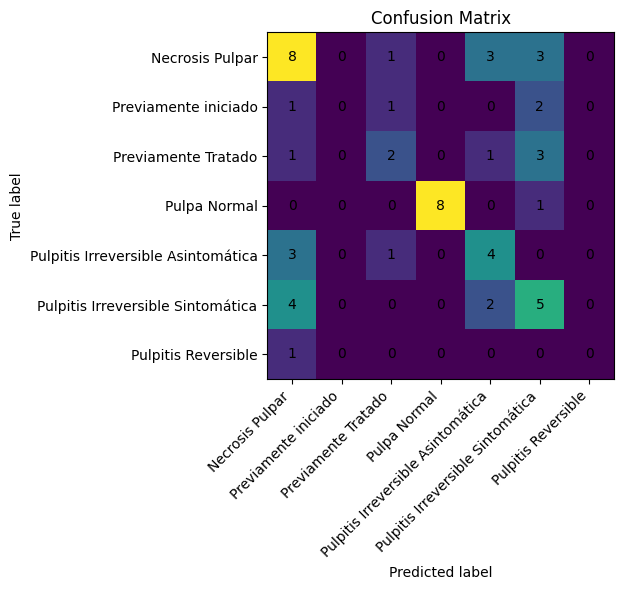

In [33]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, idx_to_class):
    labels = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))

    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(results["confusion_matrix"], idx_to_class)


=== Evaluación sobre TODO el dataset ===
Accuracy           : 0.8242
Precision macro    : 0.8640
Recall macro       : 0.7761
F1 macro           : 0.8102
Precision weighted : 0.8301
Recall weighted    : 0.8242
F1 weighted        : 0.8242

Classification report:

                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.77      0.86      0.81       100
              Previamente iniciado       0.85      0.68      0.76        25
               Previamente Tratado       0.89      0.77      0.82        43
                      Pulpa Normal       0.98      0.95      0.97        61
Pulpitis Irreversible Asintomática       0.79      0.75      0.77        56
 Pulpitis Irreversible Sintomática       0.76      0.82      0.79        74
               Pulpitis Reversible       1.00      0.60      0.75         5

                          accuracy                           0.82       364
                         macro avg       0.86      0

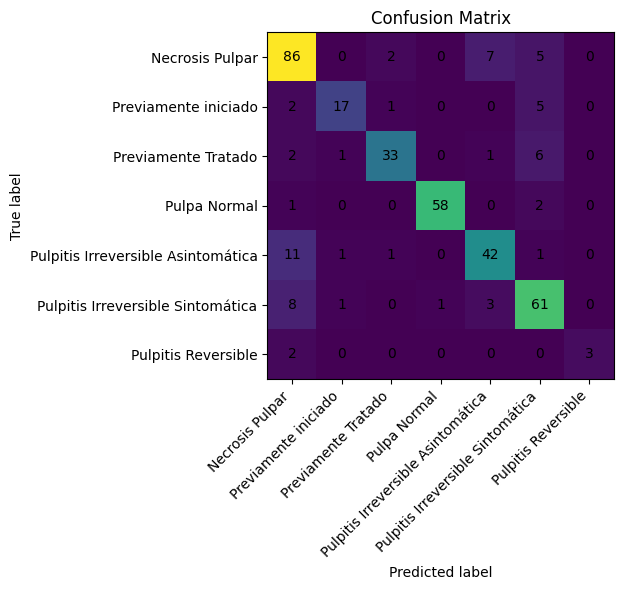

In [34]:
from torch.utils.data import DataLoader

all_loader = DataLoader(
    data_module["dataset"],
    batch_size=32,
    shuffle=False,
    num_workers=0,
)

idx_to_class = {v: k for k, v in class_to_idx.items()}

all_results = evaluate_classification_model(
    model=loaded_model,
    loader=all_loader,
    device=device,
    idx_to_class=idx_to_class,
)

print("=== Evaluación sobre TODO el dataset ===")
print(f"Accuracy           : {all_results['accuracy']:.4f}")
print(f"Precision macro    : {all_results['precision_macro']:.4f}")
print(f"Recall macro       : {all_results['recall_macro']:.4f}")
print(f"F1 macro           : {all_results['f1_macro']:.4f}")
print(f"Precision weighted : {all_results['precision_weighted']:.4f}")
print(f"Recall weighted    : {all_results['recall_weighted']:.4f}")
print(f"F1 weighted        : {all_results['f1_weighted']:.4f}")

print("\nClassification report:\n")
print(all_results["classification_report"])

print("\nConfusion matrix:\n")
print(all_results["confusion_matrix"])

plot_confusion_matrix(all_results["confusion_matrix"], idx_to_class)

# Combine the models to create the final model

In [35]:
class FullMultimodalModel(nn.Module):
    def __init__(self, embedding_extractor, fused_classifier):
        super().__init__()
        self.embedding_extractor = embedding_extractor
        self.fused_classifier = fused_classifier

    def forward(self, image, clinical_vector):
        embedding = self.embedding_extractor(image)          # [B, 1024]
        x = torch.cat([embedding, clinical_vector], dim=1)  # [B, 1035]
        logits = self.fused_classifier(x)                   # [B, num_classes]
        return logits

In [36]:
full_model = FullMultimodalModel(
    embedding_extractor=extractor,
    fused_classifier=loaded_model,
)

print(full_model)

FullMultimodalModel(
  (embedding_extractor): CNNEmbeddingExtractor(
    (features): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
      )
      (1): Sequential(
        (0): Conv2d(8, 8, kernel_size=(9, 9), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (2): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (3): Sequential(
        (0): Conv2d(16, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, m

In [37]:
#Save the full model checkpoint (including state dicts and class_to_idx)

torch.save(
    {
        "model_state_dict": full_model.state_dict(),
        "embedding_extractor_state_dict": full_model.embedding_extractor.state_dict(),
        "fused_classifier_state_dict": full_model.fused_classifier.state_dict(),
        "class_to_idx": class_to_idx,
    },
    "Models/DentalDeepGA_checkpoint.pth"
)

print("Checkpoint guardado")

Checkpoint guardado


In [38]:
#Export the full model to .pt2 format for deployment

full_model.eval()
full_model = full_model.to("cpu")

dummy_image = torch.randn(1, 1, 128, 128)
dummy_clinical = torch.randn(1, 11)

exported_program = torch.export.export(
    full_model,
    (dummy_image, dummy_clinical),
)

torch.export.save(
    exported_program,
    "Models/DentalDeepGA_model.pt2"
)

print("Modelo exportado a .pt2 correctamente")

Modelo exportado a .pt2 correctamente


# Test the old model

In [39]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)


def evaluate_image_model_on_folder_dataset(
    model,
    dataset_root,
    device,
    out_size=128,
    batch_size=1,   # aquí realmente se procesa imagen por imagen
    valid_ext=(".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif"),
    save_csv_path="predicciones_dataset.csv",
    show_confusion_matrix=True,
):
    # -------------------------------------------------
    # 1) Detectar clases por carpetas
    # -------------------------------------------------
    class_names = sorted([
        d for d in os.listdir(dataset_root)
        if os.path.isdir(os.path.join(dataset_root, d))
    ])

    label_map = {label: idx for idx, label in enumerate(class_names)}
    inv_label_map = {v: k for k, v in label_map.items()}

    print("Clases encontradas:", class_names)
    print("label_map:", label_map)

    # -------------------------------------------------
    # 2) Transform
    # -------------------------------------------------
    transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((out_size, out_size)),
        transforms.ToTensor(),
    ])

    # -------------------------------------------------
    # 3) Construir lista de samples
    # -------------------------------------------------
    samples = []

    for class_name in class_names:
        class_dir = os.path.join(dataset_root, class_name)

        for fname in sorted(os.listdir(class_dir)):
            if not fname.lower().endswith(valid_ext):
                continue

            img_path = os.path.join(class_dir, fname)

            samples.append({
                "img_path": img_path,
                "file_name": fname,
                "true_label": class_name,
                "true_idx": label_map[class_name],
            })

    df_samples = pd.DataFrame(samples)

    print("\nTotal de imágenes:", len(df_samples))
    print(df_samples.head())

    # -------------------------------------------------
    # 4) Predicción imagen por imagen
    # -------------------------------------------------
    results = []

    model = model.to(device)
    model.eval()

    for _, row in df_samples.iterrows():
        img_path = row["img_path"]
        file_name = row["file_name"]
        true_label = row["true_label"]
        true_idx = row["true_idx"]

        try:
            pil_img = Image.open(img_path).convert("RGB")
            x = transform(pil_img).unsqueeze(0).to(device)

            with torch.no_grad():
                outputs = model(x)
                probs = torch.softmax(outputs, dim=1).squeeze(0).cpu().numpy()
                pred_idx = int(np.argmax(probs))
                pred_label = inv_label_map[pred_idx]
                pred_conf = float(probs[pred_idx])

            result = {
                "img_path": img_path,
                "file_name": file_name,
                "true_label": true_label,
                "true_idx": int(true_idx),
                "pred_label": pred_label,
                "pred_idx": pred_idx,
                "pred_confidence": pred_conf,
            }

            # guardar probabilidad por clase
            for i, cls_name in enumerate(class_names):
                result[f"prob_{cls_name}"] = float(probs[i])

        except Exception as e:
            result = {
                "img_path": img_path,
                "file_name": file_name,
                "true_label": true_label,
                "true_idx": int(true_idx),
                "pred_label": f"ERROR: {str(e)}",
                "pred_idx": np.nan,
                "pred_confidence": np.nan,
            }

        results.append(result)

    df_results = pd.DataFrame(results)

    # -------------------------------------------------
    # 5) Guardar CSV
    # -------------------------------------------------
    df_results.to_csv(save_csv_path, index=False)
    print(f"\nArchivo guardado: {save_csv_path}")

    # -------------------------------------------------
    # 6) Filtrar válidos para evaluación
    # -------------------------------------------------
    df_valid = df_results.dropna(subset=["pred_idx"]).copy()
    df_valid = df_valid[
        df_valid["pred_label"].apply(lambda x: not str(x).startswith("ERROR"))
    ]

    y_true = df_valid["true_idx"].astype(int).to_numpy()
    y_pred = df_valid["pred_idx"].astype(int).to_numpy()

    print("Imágenes válidas para evaluación:", len(df_valid))

    # -------------------------------------------------
    # 7) Métricas globales
    # -------------------------------------------------
    acc = accuracy_score(y_true, y_pred)
    precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print("\n=== Métricas globales ===")
    print("Accuracy:", acc)
    print("Precision macro:", precision_macro)
    print("Recall macro:", recall_macro)
    print("F1 macro:", f1_macro)
    print("Precision weighted:", precision_weighted)
    print("Recall weighted:", recall_weighted)
    print("F1 weighted:", f1_weighted)

    # -------------------------------------------------
    # 8) Classification report
    # -------------------------------------------------
    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(len(class_names))),
        target_names=class_names,
        zero_division=0,
    )

    print("\n=== Classification report ===")
    print(report)

    # -------------------------------------------------
    # 9) Confusion matrix
    # -------------------------------------------------
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

    print("=== Confusion matrix ===")
    print(cm)

    if show_confusion_matrix:
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation="nearest", cmap="Blues")
        plt.title("Matriz de confusión")
        plt.colorbar()

        tick_marks = np.arange(len(class_names))
        plt.xticks(tick_marks, class_names, rotation=45, ha="right")
        plt.yticks(tick_marks, class_names)

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, str(cm[i, j]), ha="center", va="center")

        plt.ylabel("Etiqueta real")
        plt.xlabel("Etiqueta predicha")
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------
    # 10) Errores
    # -------------------------------------------------
    df_errors = df_valid[df_valid["true_idx"] != df_valid["pred_idx"]].copy()

    print("\nTotal de errores:", len(df_errors))
    if len(df_errors) > 0:
        print(df_errors[["file_name", "true_label", "pred_label", "pred_confidence"]].head(20))

    # -------------------------------------------------
    # 11) Conteo de predicciones
    # -------------------------------------------------
    pred_counts = df_valid["pred_label"].value_counts()
    print("\n=== Conteo de clases predichas ===")
    print(pred_counts)

    # -------------------------------------------------
    # 12) Accuracy por clase real
    # -------------------------------------------------
    per_class_acc = []

    for class_name, class_idx in label_map.items():
        df_cls = df_valid[df_valid["true_idx"] == class_idx]

        if len(df_cls) == 0:
            acc_cls = np.nan
        else:
            acc_cls = (df_cls["true_idx"] == df_cls["pred_idx"]).mean()

        per_class_acc.append({
            "class_name": class_name,
            "class_idx": class_idx,
            "n_samples": len(df_cls),
            "accuracy_in_class": acc_cls,
        })

    df_per_class_acc = pd.DataFrame(per_class_acc)

    print("\n=== Accuracy por clase ===")
    print(df_per_class_acc)

    return {
        "class_names": class_names,
        "label_map": label_map,
        "df_samples": df_samples,
        "df_results": df_results,
        "df_valid": df_valid,
        "df_errors": df_errors,
        "df_per_class_acc": df_per_class_acc,
        "confusion_matrix": cm,
        "classification_report": report,
        "metrics": {
            "accuracy": acc,
            "precision_macro": precision_macro,
            "recall_macro": recall_macro,
            "f1_macro": f1_macro,
            "precision_weighted": precision_weighted,
            "recall_weighted": recall_weighted,
            "f1_weighted": f1_weighted,
        },
    }

Clases encontradas: ['Necrosis Pulpar', 'Previamente iniciado', 'Previamente tratado', 'Pulpa Normal', 'Pulpitis irreversible asintomatica', 'Pulpitis irreversible sintomatica', 'Pulpitis reversible']
label_map: {'Necrosis Pulpar': 0, 'Previamente iniciado': 1, 'Previamente tratado': 2, 'Pulpa Normal': 3, 'Pulpitis irreversible asintomatica': 4, 'Pulpitis irreversible sintomatica': 5, 'Pulpitis reversible': 6}

Total de imágenes: 366
                                            img_path       file_name  \
0  DataSet/radiografia_dataset_original/Necrosis ...   1. OD 36.jpeg   
1  DataSet/radiografia_dataset_original/Necrosis ...   10. OD 16.jpg   
2  DataSet/radiografia_dataset_original/Necrosis ...  100. OD 16.jpg   
3  DataSet/radiografia_dataset_original/Necrosis ...   11. OD 17.jpg   
4  DataSet/radiografia_dataset_original/Necrosis ...   12. OD 46.jpg   

        true_label  true_idx  
0  Necrosis Pulpar         0  
1  Necrosis Pulpar         0  
2  Necrosis Pulpar         0  
3  Ne

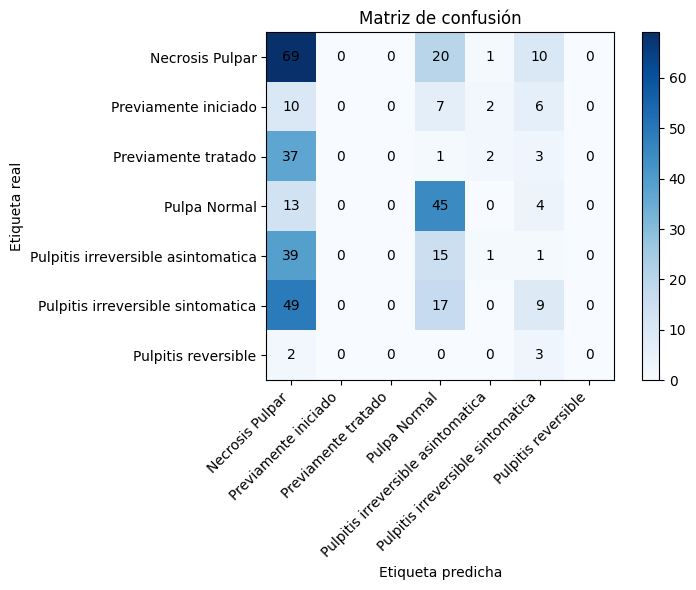


Total de errores: 242
         file_name       true_label                          pred_label  \
1    10. OD 16.jpg  Necrosis Pulpar                        Pulpa Normal   
4    12. OD 46.jpg  Necrosis Pulpar                        Pulpa Normal   
6    14. OD 16.jpg  Necrosis Pulpar                        Pulpa Normal   
8    16. OD 36.jpg  Necrosis Pulpar   Pulpitis irreversible sintomatica   
9    17. OD 16.jpg  Necrosis Pulpar   Pulpitis irreversible sintomatica   
10   18. OD 26.jpg  Necrosis Pulpar   Pulpitis irreversible sintomatica   
20   27. OD 32.jpg  Necrosis Pulpar                        Pulpa Normal   
21   28. OD 31.jpg  Necrosis Pulpar                        Pulpa Normal   
22   29. OD 41.jpg  Necrosis Pulpar                        Pulpa Normal   
23  3. OD 21 .jpeg  Necrosis Pulpar                        Pulpa Normal   
24   30. OD 42.jpg  Necrosis Pulpar                        Pulpa Normal   
26   32. OD 36.jpg  Necrosis Pulpar                        Pulpa Normal   
28

In [40]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

results_full = evaluate_image_model_on_folder_dataset(
    model=model,
    dataset_root="DataSet/radiografia_dataset_original",
    device=device,
    out_size=128,
    save_csv_path="predicciones_nuevo_dataset.csv",
    show_confusion_matrix=True,
)